In [18]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import numpy as np
import healpy as hp
import json
from tqdm import tqdm

import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC

import jax
import jax.numpy as jnp

from simulations.wrapper import simulator_for_model
from models.np_model import NPModel
from models.bulge_models import BulgeTemplates
from utils import create_mask as cm

import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'numpyro'

In [66]:
m = NPModel()

Number of pixels in ROI: 6839
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/production/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


# Poissonian fit to data

In [61]:
# data
data_dir = "../data/fermi_data_573w/fermi_data_128"
data = np.load(f"{data_dir}/fermidata_counts.npy")

mask_ps = np.load(f"../data/mask_3fgl_0p8deg.npy")
mask_roi = cm.make_mask_total(
    nside=128,
    band_mask=True, band_mask_range=2.,
    mask_ring=True, inner=0, outer=25.,
    custom_mask=mask_ps
)
mask_norm = cm.make_mask_total(
    nside=128,
    band_mask=True, band_mask_range=2.,
    mask_ring=True, inner=0, outer=25.,
)

data_masked = data[~mask_roi]
print(data_masked.shape)

np.save('mask_roi.npy', mask_roi)
np.save('mask_norm.npy', mask_norm)

(6839,)


In [15]:
label_fn_pairs = [
    ('pib', 'Opi'),
    ('ics', 'Oic'),
    ('bub', 'bub'),
    ('dsk', 'dsk_z0p3'),
    ('nfw', 'nfw_g1p2'),
    ('iso', 'iso'),
    ('psc', 'psc_3fgl'),
]
temp_dict = {}
for label, fn in label_fn_pairs:
    temp_dict[label] = np.load(f"{data_dir}/template_{fn}.npy")
    temp_dict[label] /= np.mean(temp_dict[label][~mask_norm])

# bulge
temp_dict['blg'] = BulgeTemplates(template_name='coleman2019', nside_out=128)()
temp_dict['blg'] /= np.mean(temp_dict['blg'][~mask_norm])

In [29]:
tags = ['pib', 'ics', 'bub', 'iso', 'psc', 'dsk', 'nfw', 'blg']

def model(data=None):
    mu = jnp.zeros(data.shape, dtype=jnp.float32)
    for i, k in enumerate(tags):
        S = numpyro.sample(f"S_{k}", dist.Uniform(1e-4, 50)) # mean count per pixel. data ~ 2
        mu += S * temp_dict[k][~mask_roi]
    return numpyro.sample('obs', dist.Poisson(mu), obs=data)

def fit_nuts(
        rng_key, model, num_chains=16, num_warmup=1000, num_samples=2000, step_size=0.1,
        **model_static_kwargs
    ):
    
    kernel = NUTS(model, max_tree_depth=4, dense_mass=False, step_size=step_size)
    nuts_mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains, chain_method='vectorized')
    nuts_mcmc.run(rng_key, **model_static_kwargs)
    
    return nuts_mcmc

In [30]:
samples = fit_nuts(jax.random.PRNGKey(42), model, data=data_masked)

sample: 100%|██████████| 3000/3000 [00:22<00:00, 134.67it/s]


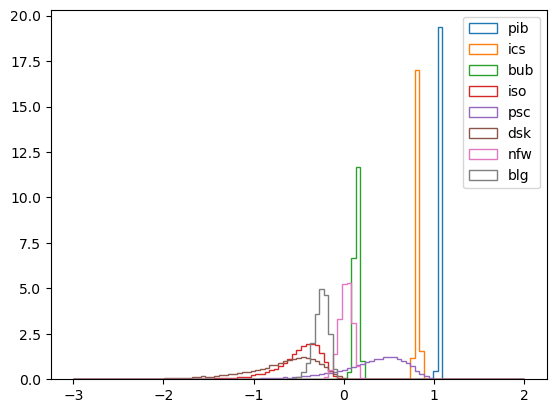

In [31]:
bins = np.linspace(-3, 2, 100)
for k in tags:
    plt.hist(np.log10(samples.get_samples()[f"S_{k}"]), bins=bins, histtype='step', label=k, density=True)
plt.legend();

In [32]:
n_pix_mask_norm = np.sum(~mask_norm)
print(n_pix_mask_norm, 'total pixels')
for k in tags:
    s = samples.get_samples()[f"S_{k}"]
    print(f'{k} {s.mean():.3f} | {np.quantile(s, [0.05, 0.95])} | {s.mean()*n_pix_mask_norm:.0f} total photons')

8292 total pixels
pib 11.241 | [11.02388987 11.45672665] | 93210 total photons
ics 6.553 | [6.10490496 6.94493174] | 54335 total photons
bub 1.383 | [1.23890799 1.51972459] | 11466 total photons
iso 0.360 | [0.09032237 0.64600727] | 2986 total photons
psc 2.688 | [0.31194389 6.19792655] | 22290 total photons
dsk 0.285 | [0.0254145  0.67427382] | 2361 total photons
nfw 1.059 | [0.78682304 1.33690695] | 8783 total photons
blg 0.570 | [0.40044889 0.7358615 ] | 4726 total photons


In [36]:
truth_dict = {
    'S_pib' : 11.2,
    'theta_pib' : [1., 0., 0.],
    'S_ics' : 6.5,
    'theta_ics' : [1., 0., 0.],
    'S_bub' : 1.4,
    'S_iso' : 0.4,
    'S_psc' : 2.7,
    'S_gce' : 0.6,
    'f_bulge_poiss' : 0.2,
    'theta_bulge_poiss' : [0, 0, 0, 0, 1],
    'gamma_poiss' : 1.0,
    'Sps_gce': 1.0,
    'n1_gce' : 5.0,
    'n2_gce' : 1.0,
    'n3_gce' : -5.5,
    'sb1_gce' : 10.0,
    'lambdas_gce' : 0.4,
    'f_bulge_ps' : 0.8,
    'theta_bulge_ps' : [0, 0, 0, 0, 1],
    'gamma_ps' : 1.2,
    'Sps_dsk' : 0.3,
    'zs' : 0.6,
    'C' : 6.0,
    'n1_dsk' : 5.0,
    'n2_dsk' : 1.0,
    'n3_dsk' : -5.5,
    'sb1_dsk' : 15.0,
    'lambdas_dsk' : 0.7,
}
json.dump(truth_dict, open('truth_dict.json', 'w'), indent=4)

In [2]:
import json

In [4]:
truth_dict_flat = {
    'S_pib' : 11.2,
    'theta_pib_ModelO' : 1.,
    'theta_pib_ModelA' : 1.,
    'theta_pib_ModelF' : 1.,
    'S_ics' : 6.5,
    'theta_ics_ModelO' : 1.,
    'theta_ics_ModelA' : 1.,
    'theta_ics_ModelF' : 1.,
    'S_bub' : 1.4,
    'S_iso' : 0.4,
    'S_psc' : 2.7,
    'S_gce' : 0.6,
    'f_bulge_poiss' : 0.2,
    'theta_poiss_mcdermott2022' : 1.,
    'theta_poiss_mcdermott2022_bbp' : 0.,
    'theta_poiss_mcdermott2022_x' : 0.,
    'theta_poiss_macias2019' : 0.,
    'theta_poiss_coleman2019' : 0.,
    'gamma_poiss' : 1.0,
    'Sps_gce': 1.0,
    'n1_gce' : 5.0,
    'n2_gce' : 1.0,
    'n3_gce' : -5.5,
    'sb1_gce' : 10.0,
    'lambdas_gce' : 0.4,
    'f_bulge_ps' : 0.8,
    'theta_ps_mcdermott2022' : 1.,
    'theta_ps_mcdermott2022_bbp' : 0.,
    'theta_ps_mcdermott2022_x' : 0.,
    'theta_ps_macias2019' : 0.,
    'theta_ps_coleman2019' : 0.,
    'gamma_ps' : 1.2,
    'Sps_dsk' : 0.3,
    'zs' : 0.6,
    'C' : 6.0,
    'n1_dsk' : 5.0,
    'n2_dsk' : 1.0,
    'n3_dsk' : -5.5,
    'sb1_dsk' : 15.0,
    'lambdas_dsk' : 0.7,
}
json.dump(truth_dict_flat, open('truth_dict_flat.json', 'w'), indent=4)

In [ ]:
["Alm_0", "Alm_1", "Alm_2", "Alm_3", "Alm_4", "Alm_5", "C", "S_bub", "S_gce", "S_ics", "S_iso", "S_pib", "S_psc", "Sps_dsk", "Sps_gce",
 "f_bulge_poiss", "f_bulge_ps", "gamma_poiss", "gamma_ps", "lambdas_dsk", "lambdas_gce", "n1_dsk", "n1_gce", "n2_dsk", "n2_gce", "n3_dsk", "n3_gce", "sb1_dsk", "sb1_gce",
 "theta_poiss_mcdermott2022", "theta_poiss_mcdermott2022_bbp", "theta_poiss_mcdermott2022_x", "theta_poiss_macias2019", "theta_poiss_coleman2019",
 "theta_ps_mcdermott2022", "theta_ps_mcdermott2022_bbp", "theta_ps_mcdermott2022_x", "theta_ps_macias2019", "theta_ps_coleman2019",
 "theta_ics_ModelO", "theta_ics_ModelA", "theta_ics_ModelF", "theta_pib_ModelO", "theta_pib_ModelA", "theta_pib_ModelF",
 "zs"]

In [37]:
z = simulator_for_model(m, truth_dict, no_psc_mask=True)

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/jax/_src/numpy/lax_numpy.py:3662: UserWarning: 'kind' argument to argsort is ignored; only 'stable' sorts are supported.
  warnings.warn("'kind' argument to argsort is ignored; only 'stable' sorts "


In [59]:
sims[0].shape

(8292,)

In [57]:
sims = []
for _ in tqdm(range(30)):
    sims.append(simulator_for_model(m, truth_dict))
sims = np.array(sims)
np.save("sim_truth_n30.npy", sims)

100%|██████████| 30/30 [00:49<00:00,  1.64s/it]


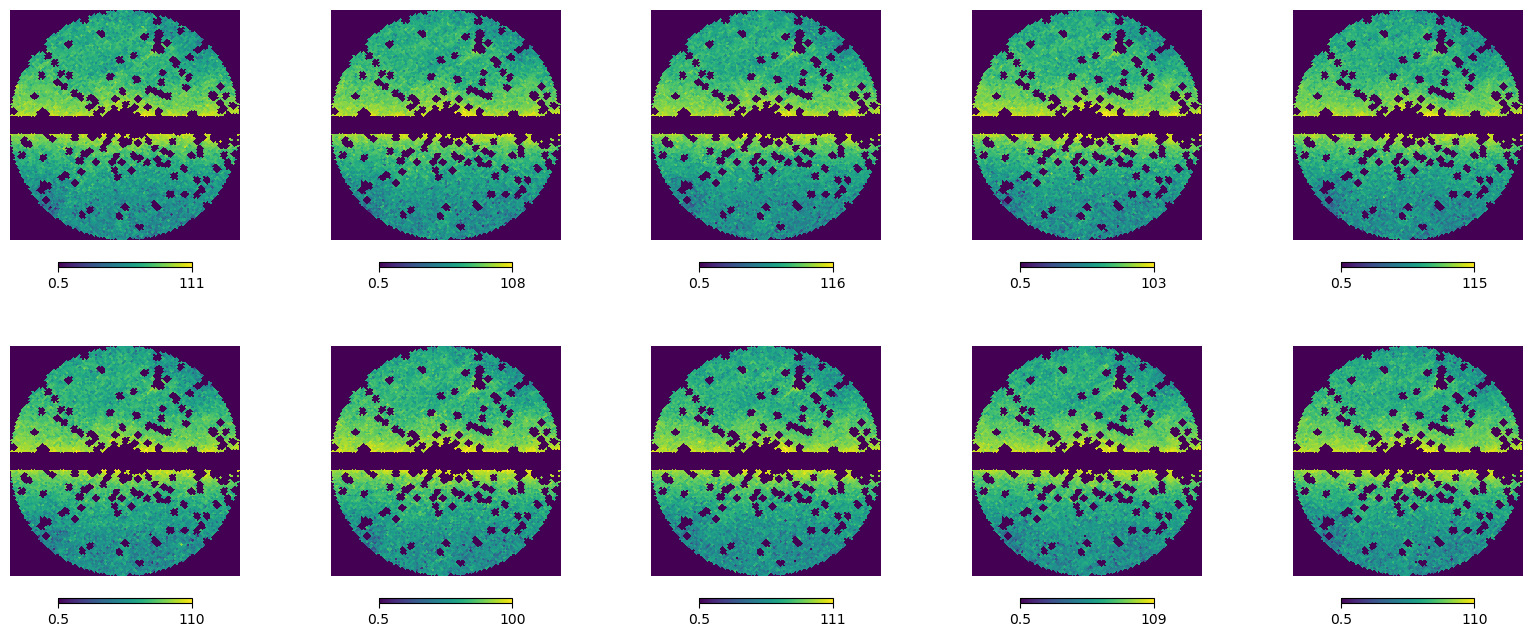

In [60]:
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i in range(10):
    ax = axs.flat[i]
    z_full = np.zeros(hp.nside2npix(128))
    z_full[~mask_norm] = sims[i]
    plt.sca(ax)
    hp.cartview(np.clip(z_full, 0.5, None), lonra=[-25, 25], latra=[-25, 25], hold=True, title='', norm='log')

# Test fit

In [1]:
import pickle
import matplotlib.pyplot as plt

import sys
sys.path.append("..")

from utils.validation import plot_coverage

In [2]:
z = pickle.load(open('../outputs/fit/svi_240817_singledeltapsf/p_nominal_actual_dict.p', 'rb'))

In [20]:
z.keys()

dict_keys(['Sps_gce', 'n1_gce', 'n2_gce', 'n3_gce', 'sb1_gce', 'lambdas_gce'])

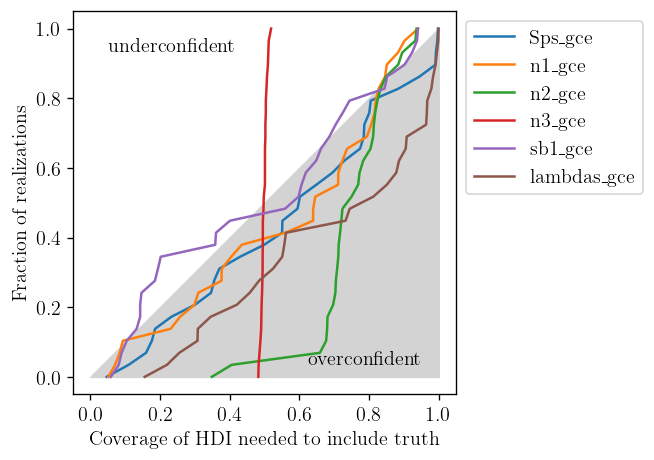

In [21]:
# labels = ['S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'S_psc', 'Sps_dsk', 'Sps_gce',
#           'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs']
#labels = ['S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'S_psc', 'Sps_dsk', 'Sps_gce']
labels = ['Sps_gce', 'n1_gce', 'n2_gce', 'n3_gce', 'sb1_gce', 'lambdas_gce']
probs = [z[k] for k in labels]

fig, ax = plt.subplots()

n_run = len(probs[0])
ax.fill_between([0,1], [0,1], color='lightgray')
if labels is None:
    labels = [None for _ in probs]
for prob, label in zip(probs, labels):
    ax.plot(prob[0], prob[1], label=label)

# invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)
# ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
# ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations')
ax.text(0.95, 0.05, 'overconfident', ha='right', va='center')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='center')

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout()

In [ ]:
labels = ['S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'S_psc', 'Sps_dsk', 'Sps_gce',
          'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs']
probs = [z[k] for k in labels]

fig, ax = plt.subplots()

n_run = len(probs[0])
ax.fill_between([0,1], [0,1], color='lightgray')
if labels is None:
    labels = [None for _ in probs]
for prob, label in zip(probs, labels):
    ax.plot(prob[0], prob[1], label=label)

# invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)
# ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
# ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations')
ax.text(0.95, 0.05, 'overconfident', ha='right', va='center')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='center')

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout()

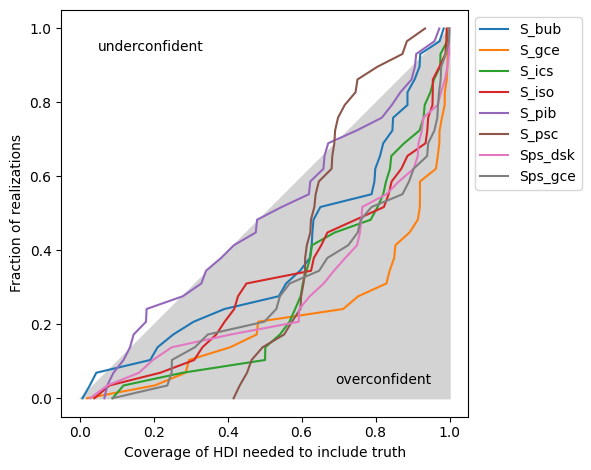

In [6]:
labels = ['S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'S_psc', 'Sps_dsk', 'Sps_gce']
probs = [z[k] for k in labels]

fig, ax = plt.subplots()

n_run = len(probs[0])
ax.fill_between([0,1], [0,1], color='lightgray')
if labels is None:
    labels = [None for _ in probs]
for prob, label in zip(probs, labels):
    ax.plot(prob[0], prob[1], label=label)

# invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)
# ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
# ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations')
ax.text(0.95, 0.05, 'overconfident', ha='right', va='center')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='center')

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout()

In [3]:
from utils.multi_corner import multi_corner
import json

In [24]:
labels = ['S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'S_psc', 'Sps_dsk', 'Sps_gce',
          'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs']
s_in = {}
labels_dict = {}
for ns in [5000, 10000, 15000]:
    nskey = f'ns{ns}'
    s = pickle.load(open(f'../outputs/fit/svi_240809_sviquality/svi_samples_i0_n50000_ns{ns}.p', 'rb'))
    s_in[nskey] = {k: s[k] for k in labels}
    labels_dict[nskey] = nskey

truth_dict = json.load(open('truth_dict_flat.json', 'r'))
t_in = {k: truth_dict[k] for k in labels}

colors_dict = {
    'ns5000'  : 'C0',
    'ns10000' : 'C1',
    'ns15000' : 'C2',
}

s_in = {'svi' : {k: s[k] for k in labels}}
t_in = {k: truth_dict[k] for k in labels}
colors_dict = {'svi' : 'C0'}
labels_dict = {'svi' : 'SVI'}

multi_corner(s_in, labels, point_est=t_in, colors_dict=colors_dict, labels_dict=labels_dict)

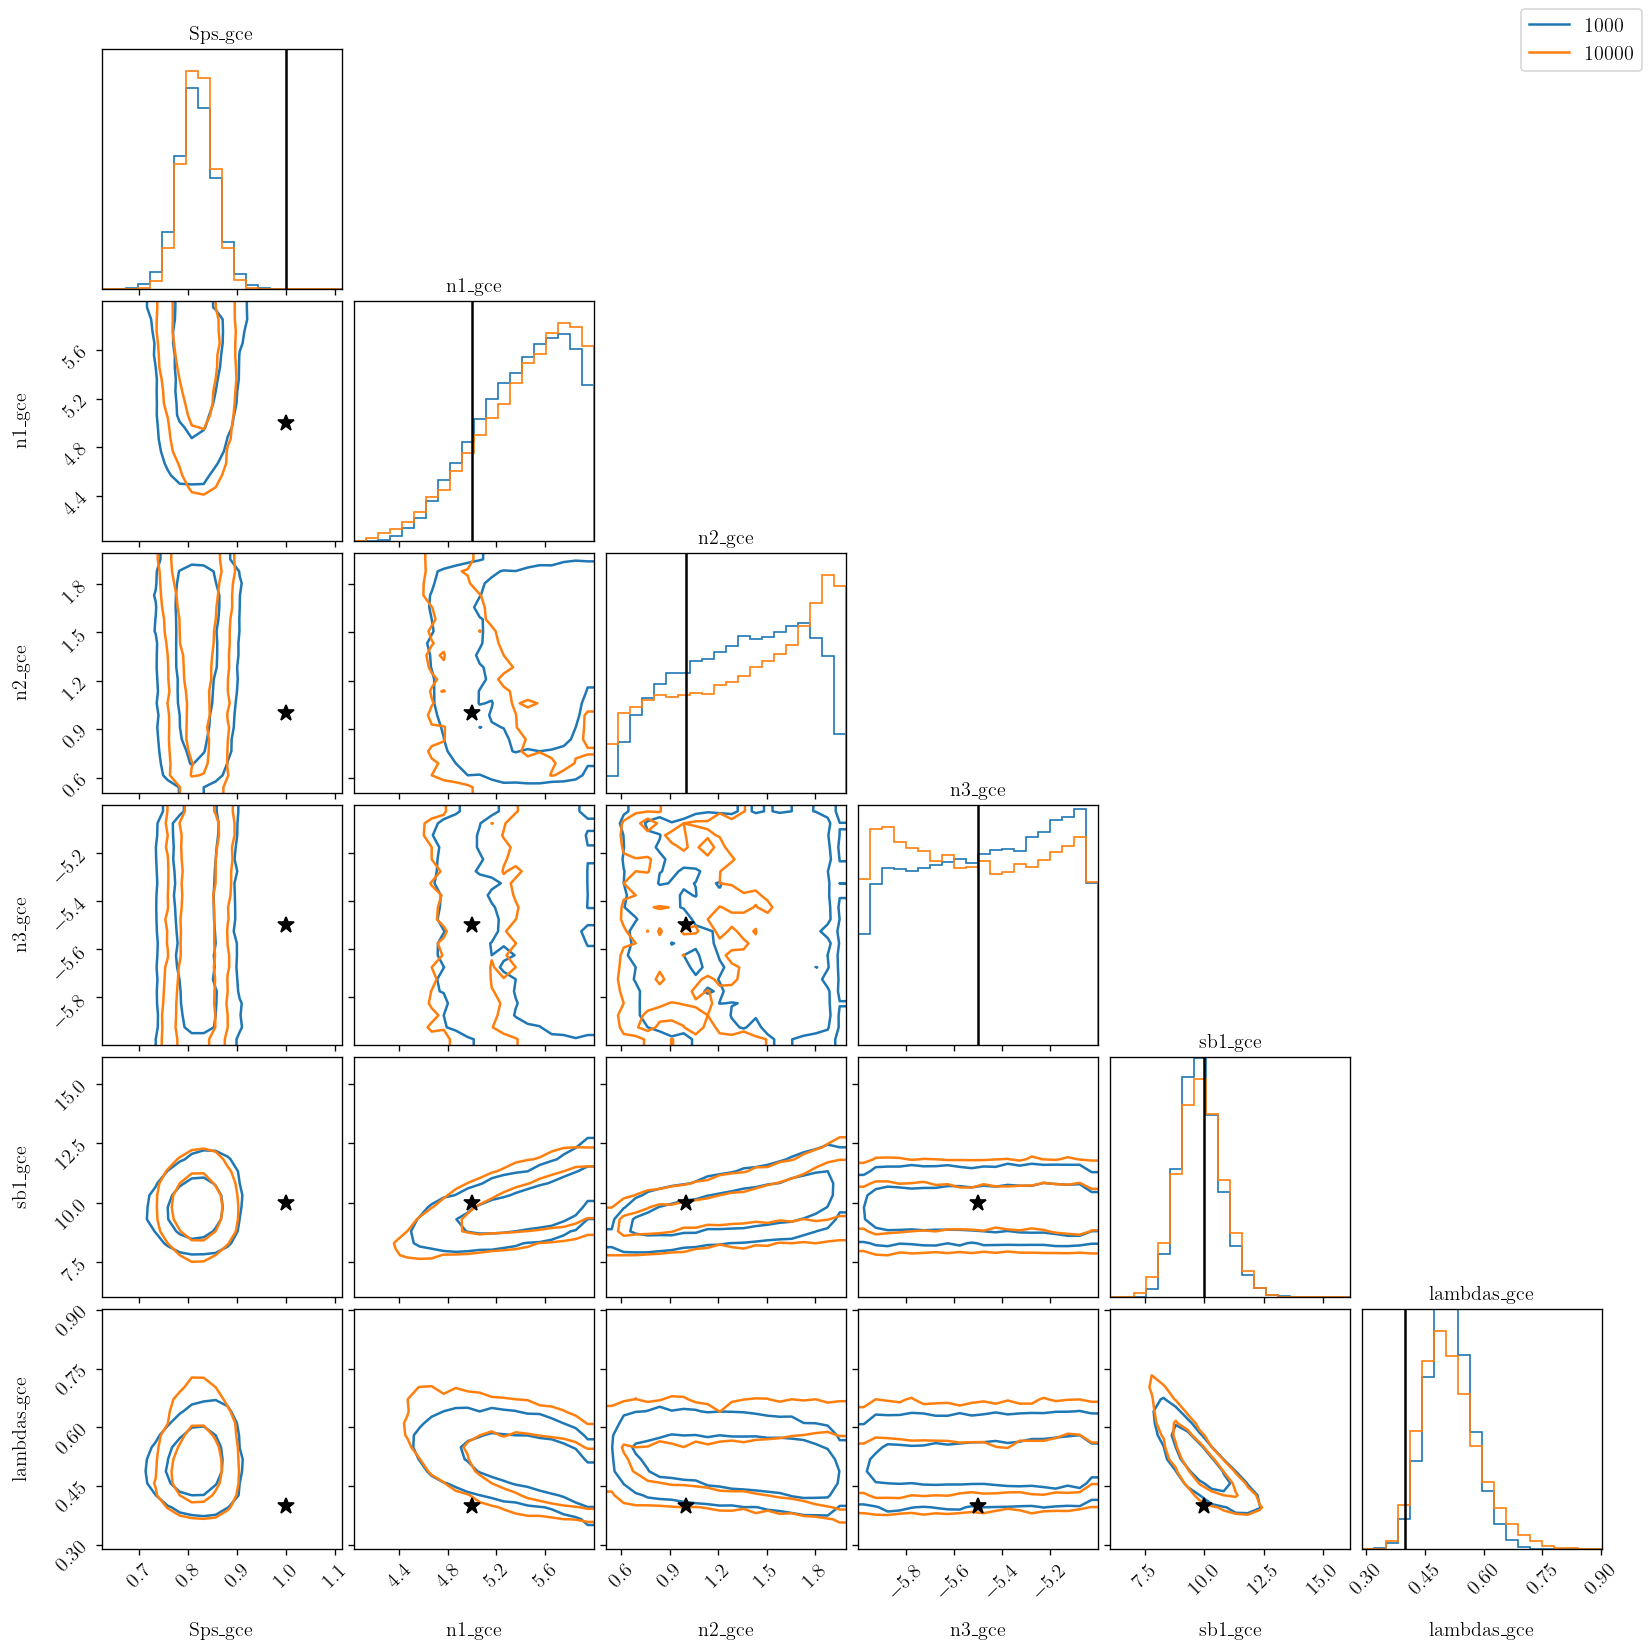

In [5]:
labels = list(z.keys())
s_in = {}
labels_dict = {}
for i, x in enumerate([1000, 10000]):
    key = str(i)
    s = pickle.load(open(f'../outputs/fit/svi_240817_singledeltapsf/svi_samples_i0_n50000_ns{x}.p', 'rb'))
    s_in[key] = {k: s[k] for k in labels}
    labels_dict[key] = str(x)

truth_dict = json.load(open('truth_dict_flat.json', 'r'))
t_in = {k: truth_dict[k] for k in labels}

colors_dict = {
    '0' : 'C0',
    '1' : 'C1',
}

multi_corner(s_in, labels, point_est=t_in, colors_dict=colors_dict, labels_dict=labels_dict)

## View data

In [6]:
import numpy as np
import healpy as hp

In [15]:
d = np.load("../outputs/simulations/sim_Spsgce_deltapsf_n30.npy")
mn = np.load("mask_norm.npy")
mr = np.load("mask_roi.npy")

In [16]:
dfull = np.zeros((30, hp.nside2npix(128)))
dfull[:, ~mn] = d
np.mean(dfull[:,~mr])

0.8504216015986743

In [12]:
np.sum(~mr) / np.sum(~mn)

0.8247708634828751

In [ ]:
a = np.load("../data/fermi_data_573w/fermi_data_128/template_nfw_g1p2.npy")
b = a.copy()
b[mn] = 0.01
hp.cartview(b, lonra=[-25, 25], latra=[-25, 25], norm='log', title='NFW template')

In [14]:
np.mean(a[~mr]) / np.mean(a[~mn])

0.852570116561151

In [20]:
dfull = np.zeros(hp.nside2npix(128))
dfull[~mn] = d[0]

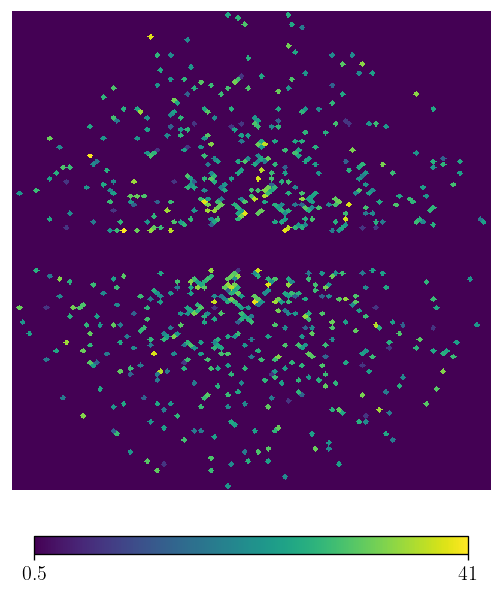

In [21]:
hp.cartview(np.clip(dfull, 0.5, None), lonra=[-25, 25], latra=[-25, 25], title='', norm='log')

In [25]:
import sys
import numpy as np

wdir = "/n/home07/yitians/fermi/fermi-prob-prog/production"
sys.path.append(f"{wdir}/..")
from simulations.wrapper import simulator

sys.path.append("..")
from models.psf import KingPSF
from utils import create_mask as cm

nm = np.load("mask_norm.npy")


def simulator_for_model(m, vd, no_psc_mask=False, delta_psf=False, no_plane_mask=False, psf_scheme='original'):
    """Wrapper for simulator function.

    Args:
        m (NPModel): model object
        vd (dict): Dictionary of truth parameters
    """

    # mask
    mask_outer = cm.make_mask_total(nside=m.nside, band_mask=False, mask_ring=True, inner=0, outer=25)

    # poiss: 0
    nm = nm
    temps_poiss = [m.temp_iso / np.mean(m.temp_iso[~nm])]
    temps_poiss = [np.array(t) for t in temps_poiss]
    theta = [0]

    # ps: nfw+blg*5 dsk
    # temp_ps
    temp_ps_nfw = m.nfw_template.get_NFW2_template(gamma=1.2) # we are going to assume this is not normalized
    temp_ps_nfw /= np.mean(temp_ps_nfw[~nm])
    temp_ps_gce = temp_ps_nfw

    temps_ps = []
    if vd['Sps_gce'] > 0:
        temps_ps.append(np.array(temp_ps_gce))
        # theta[0] should be expected photon count per pixel in normalization mask region
        theta += [vd['Sps_gce'], vd['n1_gce'], vd['n2_gce'], vd['n3_gce'], vd['sb1_gce'], vd['lambdas_gce'] * vd['sb1_gce']]

    #mask_sim = np.zeros_like(m.data, dtype=bool) # simulate all
    mask_sim = np.array(m.normalization_mask)
    mask_normalize_counts = np.array(m.normalization_mask)
    mask_roi = np.array(m.mask_roi)
    if no_psc_mask:
        mask_roi = np.array(m.normalization_mask)
    if no_plane_mask:
        mask_roi = np.array(mask_outer)

    if delta_psf:
        sigma = np.deg2rad(0.001) / 3
        psf_r_func = lambda r: np.exp(-0.5 * (r / sigma) ** 2) / (2 * np.pi * sigma ** 2)
    else:
        kp = KingPSF()
        psf_r_func = lambda r: kp.psf_fermi_r(r)
    exp_map = np.array(m.exposure_map)

    return simulator(theta, temps_poiss, temps_ps, mask_sim, mask_normalize_counts, mask_roi, psf_r_func, exp_map, psf_scheme=psf_scheme)[0]

In [23]:
simulator_for_model

## tmp

In [58]:
n = 100000
x = np.random.normal(size=n)
y = np.random.normal(size=n)
z = np.random.normal(size=n)
xy = np.sqrt(x**2 + y**2)
theta = np.arctan2(xy, z)

In [66]:
theta2 = 2*np.arcsin(np.sqrt(np.random.uniform(size=n)))

In [68]:
theta3 = np.arccos(np.random.uniform(-1, 1, size=n))

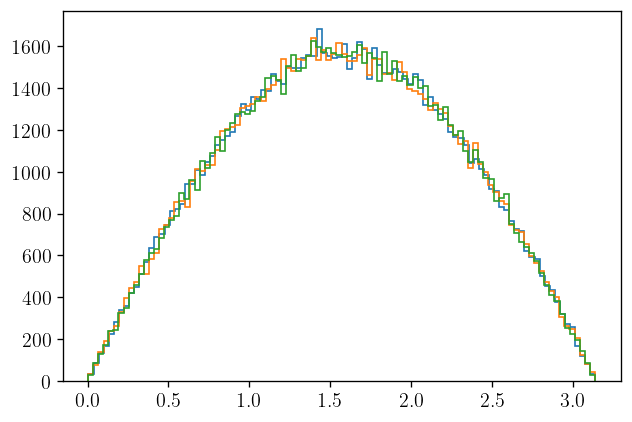

In [69]:
plt.hist(theta, bins=100, histtype='step');
plt.hist(theta2, bins=100, histtype='step');
plt.hist(theta3, bins=100, histtype='step');

In [ ]:
np.arctan2?

## GCE norm

In [3]:
import healpy as hp
import numpy as np